В этом блоке переобучается и логируется финальная production-модель **X-Learner (CatBoost)**.

Выбор модели обоснован в предыдущих аналитических разделах ноутбука (см. `DL-ml-models\jupyter_models_analysis\Uplift_ML_DL_Comparison.ipynb` и `Classic-ml-models\jupyter_results_comparison\All_models-new_feats_analysis.ipynb`), где были сравнены:
- классические ML uplift-модели;
- DL uplift-модели;
- накопительные uplift-метрики;
- бизнес-метрики;
- non-cumulative uplift by percentile.

Именно по совокупности этих критериев `X-Learner (CatBoost)` был выбран как финальный production-кандидат, а `CatBoostClassifier` - как бейзлайн.

Подробные аналитические выкладки также были представлены в предшедствующей исследовательской части, однако суммарный тезис по X-Learner можно представить в следующей формулировке: данная модель позволяет не только аккумулировать топ-клиентов по значениию uplift, но и успешно выявляет клиентов, которые подпадают под категорию убеждаемых и которые в случае отсутствия коммуникации не выполнили бы целевое действие. Этот тезис подверждается сопоставлением как накопительных и ненакопительных метрик между моделями, так и бизнес-метриками по инкрементальному эффекту (для подробной отчетности см. `Uplift_ML_DL_Comparison.ipynb`). T-Learner, в свою очередь, является второй по качеству моделью, однако проигрывает итоговой версии в фиксации топ-сегмента клиентов, предпочитая выбирать тех, кто и так бы произвел целевое действие независимо от коммуникации. Сравнение ML-моделей со стандартным бейзлайном (CatBoost) доступно в `Classic-ml-models\jupyter_results_comparison\Models-vs-baseline_analysis.ipynb`.

Описание параметров и итогов по  `X-Learner (CatBoost)` также представлены в PROD.md после пайплайна запуска mlflow и экспериментов.

# Импорты и вспомогательные функции

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from IPython.display import display, HTML

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

from catboost import CatBoostClassifier, CatBoostRegressor
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    weighted_average_uplift,
    uplift_at_k,
    uplift_by_percentile
)
from sklift.viz import plot_uplift_by_percentile

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from helpers.feature_extraction_expanded import *
from helpers.classic_ml_models import *
from helpers.clusterization_features_extraction import *
from helpers.metrics import *

# Подготовка MLflow

В MLflow логируются:
- гиперпараметры финальной модели;
- фиксированный `random_seed`;
- используемый feature extractor;
- кластеризационный пайплайн;
- train / test uplift-метрики;
- percentile uplift tables;
- зарегистрированные компоненты модели.

Это необходимо для воспроизводимости финального run и для прозрачной фиксации production-версии модели.

In [2]:
os.environ["MLFLOW_TRACKING_URI"] = "http://localhost:5000"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin"

In [3]:
import mlflow
import mlflow.catboost
import mlflow.sklearn

# Фиксация seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Настройка MLflow
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000"))
mlflow.set_experiment("X-Learner CatBoost")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

MLflow tracking URI: http://localhost:5000


# Подготовка датасета

In [4]:
dataset = fetch_x5()
data = dataset.data

In [5]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


In [6]:
strata_all = pd.Series(t_all).astype(str) + '_' + pd.Series(y_all).astype(str)

x_train_full, x_test_holdout, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    X_all,
    y_all,
    t_all,
    test_size=0.2,
    random_state=42,
    stratify=strata_all
)

print(x_train_full.shape, x_test_holdout.shape)

(160031, 45) (40008, 45)


In [7]:
strata_train_full = pd.Series(t_train_full).astype(str) + '_' + pd.Series(y_train_full).astype(str)

x_train_core, x_val_micro, y_train_core, y_val_micro, t_train_core, t_val_micro = train_test_split(
    x_train_full,
    y_train_full,
    t_train_full,
    test_size=0.15,
    random_state=42,
    stratify=strata_train_full
)

print('train_core:', x_train_core.shape)
print('val_micro:', x_val_micro.shape)
print('test_holdout:', x_test_holdout.shape)

train_core: (136026, 45)
val_micro: (24005, 45)
test_holdout: (40008, 45)


In [8]:
current_num_cols_core = x_train_core.select_dtypes(include=['number']).columns.tolist()
clusterizer_micro = UmapClusterTransformer(num_cols=current_num_cols_core, n_clusters=5)

x_train_core_clust = clusterizer_micro.fit_transform(x_train_core)
x_val_micro_clust = clusterizer_micro.transform(x_val_micro)

cat_cols_core = x_train_core_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_core = x_train_core_clust.select_dtypes(include=['number']).columns.tolist()

In [9]:
current_num_cols = x_train_full.select_dtypes(include=['number']).columns.tolist()
clusterizer_full = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

x_train_full_clust = clusterizer_full.fit_transform(x_train_full)
x_test_holdout_clust = clusterizer_full.transform(x_test_holdout)

cat_cols_full = x_train_full_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_full = x_train_full_clust.select_dtypes(include=['number']).columns.tolist()

# Обучение и логирование X-learner

Хелперы для логирования метрик:

In [10]:
def sanitize_metric_name(name: str) -> str:
    return (
        name.replace(' ', '_')
            .replace('@', '_at_')
            .replace('%', 'pct')
            .replace('/', '_')
            .replace('-', '_')
    )

def log_metric_dict(metrics_dict, prefix):
    safe_metrics = {}
    for k, v in metrics_dict.items():
        if pd.notna(v):
            safe_metrics[f"{prefix}_{sanitize_metric_name(k)}"] = float(v)
    mlflow.log_metrics(safe_metrics)

def save_and_log_percentile_table(df_pct, artifact_prefix):
    csv_path = f"{artifact_prefix}_percentile_table.csv"
    html_path = f"{artifact_prefix}_percentile_table.html"

    df_pct.to_csv(csv_path, index=False)
    df_pct.to_html(html_path, index=False)

    mlflow.log_artifact(csv_path)
    mlflow.log_artifact(html_path)

    for _, row in df_pct.iterrows():
        pct = str(row['percentile']).replace('-', '_').replace('%', 'pct')
        if pd.notna(row['uplift']):
            mlflow.log_metric(f"{artifact_prefix}_uplift_{pct}", float(row['uplift']))
        if pd.notna(row['response_rate_treatment']):
            mlflow.log_metric(f"{artifact_prefix}_rr_treatment_{pct}", float(row['response_rate_treatment']))
        if pd.notna(row['response_rate_control']):
            mlflow.log_metric(f"{artifact_prefix}_rr_control_{pct}", float(row['response_rate_control']))

In [11]:
from mlflow.tracking import MlflowClient

with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"MLflow run ID: {run_id}")

    # params
    mlflow.log_params({f"outcome_model_{k}": v for k, v in XL_OUTCOME_CATBOOST_PARAMS.items()})
    mlflow.log_params({f"effect_model_{k}": v for k, v in XL_EFFECT_CATBOOST_PARAMS.items()})
    mlflow.log_params({f"propensity_model_{k}": v for k, v in XL_PROPENSITY_CATBOOST_PARAMS.items()})

    mlflow.log_param("random_seed", RANDOM_SEED)
    mlflow.log_param("holdout_size", 0.2)
    mlflow.log_param("micro_validation_size_inside_train", 0.15)
    mlflow.log_param("feature_extractor", "UpliftFeatureExtractorExpanded")
    mlflow.log_param("clusterizer", "UmapClusterTransformer")
    mlflow.log_param("final_model", "X-Learner (CatBoost)")
    mlflow.log_param("baseline_model", "T-Learner (LogReg)")

    # model for train / val logging
    x_learner_val = build_x_learner_catboost(cat_features=cat_cols_core, use_calibration=True)
    x_learner_val.outcome_learner = CalibratedClassifierCV(
        x_learner_val.outcome_learner,
        method='isotonic',
        cv=3
    )
    x_learner_val.propensity_learner = CalibratedClassifierCV(
        x_learner_val.propensity_learner,
        method='isotonic',
        cv=3
    )

    x_learner_val.fit(x_train_core_clust, y_train_core, t_train_core)

    preds_x_train_core = x_learner_val.predict(x_train_core_clust)
    preds_x_val_micro = x_learner_val.predict(x_val_micro_clust)

    train_metrics = calculate_metrics(y_train_core, preds_x_train_core, t_train_core)
    val_metrics = calculate_metrics(y_val_micro, preds_x_val_micro, t_val_micro)

    log_metric_dict(train_metrics, "train")
    log_metric_dict(val_metrics, "val")

    train_pct_df = get_uplift_percentile_table(y_train_core, preds_x_train_core, t_train_core, bins=10)
    val_pct_df = get_uplift_percentile_table(y_val_micro, preds_x_val_micro, t_val_micro, bins=10)

    save_and_log_percentile_table(train_pct_df, "train")
    save_and_log_percentile_table(val_pct_df, "val")

    # final production model on full train
    x_learner_full = build_x_learner_catboost(cat_features=cat_cols_full, use_calibration=True)
    x_learner_full.outcome_learner = CalibratedClassifierCV(
        x_learner_full.outcome_learner,
        method='isotonic',
        cv=3
    )
    x_learner_full.propensity_learner = CalibratedClassifierCV(
        x_learner_full.propensity_learner,
        method='isotonic',
        cv=3
    )

    x_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)

    preds_x_test = x_learner_full.predict(x_test_holdout_clust)
    test_metrics = calculate_metrics(y_test_holdout, preds_x_test, t_test_holdout)

    log_metric_dict(test_metrics, "test")

    test_pct_df = get_uplift_percentile_table(y_test_holdout, preds_x_test, t_test_holdout, bins=10)
    save_and_log_percentile_table(test_pct_df, "test")

    # prediction examples
    pred_examples = x_test_holdout.copy().head(20).copy()
    pred_examples["y_true"] = y_test_holdout[:20]
    pred_examples["treatment"] = t_test_holdout[:20]
    pred_examples["uplift_pred"] = preds_x_test[:20]

    pred_examples_path = "prediction_examples.csv"
    pred_examples.to_csv(pred_examples_path, index=False)
    mlflow.log_artifact(pred_examples_path)

    # register model components
    mlflow.catboost.log_model(
        x_learner_full.model_tau_0,
        "model_tau_0",
        registered_model_name="model_tau_0"
    )
    mlflow.catboost.log_model(
        x_learner_full.model_tau_1,
        "model_tau_1",
        registered_model_name="model_tau_1"
    )
    mlflow.sklearn.log_model(
        x_learner_full.model_propensity,
        "model_propensity",
        registered_model_name="model_propensity"
    )

    print("Models registered in MLflow Registry")

MLflow run ID: b4458e928b344e60a7ea4122869c180b
0:	learn: 0.6842127	total: 186ms	remaining: 27.2s
100:	learn: 0.5579672	total: 3.76s	remaining: 1.71s
146:	learn: 0.5553411	total: 5.41s	remaining: 0us
0:	learn: 0.6834176	total: 35.3ms	remaining: 5.15s
100:	learn: 0.5566057	total: 3.56s	remaining: 1.62s
146:	learn: 0.5539650	total: 5.17s	remaining: 0us
0:	learn: 0.6836636	total: 33.7ms	remaining: 4.92s
100:	learn: 0.5559236	total: 3.58s	remaining: 1.63s
146:	learn: 0.5530370	total: 5.23s	remaining: 0us
0:	learn: 0.6831496	total: 34.1ms	remaining: 4.98s
100:	learn: 0.5434896	total: 3.63s	remaining: 1.66s
146:	learn: 0.5405026	total: 5.27s	remaining: 0us
0:	learn: 0.6833628	total: 32.2ms	remaining: 4.7s
100:	learn: 0.5464072	total: 3.98s	remaining: 1.81s
146:	learn: 0.5431495	total: 5.75s	remaining: 0us
0:	learn: 0.6834651	total: 37.1ms	remaining: 5.42s
100:	learn: 0.5480213	total: 3.92s	remaining: 1.78s
146:	learn: 0.5449073	total: 5.72s	remaining: 0us
0:	learn: 0.4359896	total: 32.5ms	re

2026/06/02 17:41:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'model_tau_0'.
2026/06/02 17:41:56 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: model_tau_0, version 1
Created version '1' of model 'model_tau_0'.
2026/06/02 17:41:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'model_tau_1'.
2026/06/02 17:41:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: model_tau_1, version 1
Created version '1' of model 'model_tau_1'.
2026/06/02 17:42:02 WARNING mlflow.models.model: Model logged without a signature and input ex

Models registered in MLflow Registry
🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


Created version '1' of model 'model_propensity'.


In [12]:
client = MlflowClient()

for model_name in ["model_tau_0", "model_tau_1", "model_propensity"]:
    versions = client.search_model_versions(f"name='{model_name}'")
    print(f"\n{model_name}")
    for v in versions:
        print(f"version={v.version}, current_stage={v.current_stage}, run_id={v.run_id}, tags={dict(v.tags)}")


model_tau_0
version=1, current_stage=None, run_id=b4458e928b344e60a7ea4122869c180b, tags={}

model_tau_1
version=1, current_stage=None, run_id=b4458e928b344e60a7ea4122869c180b, tags={}

model_propensity
version=1, current_stage=None, run_id=b4458e928b344e60a7ea4122869c180b, tags={}


# Артефакты (графики)

Добавляем артефакты обучения.

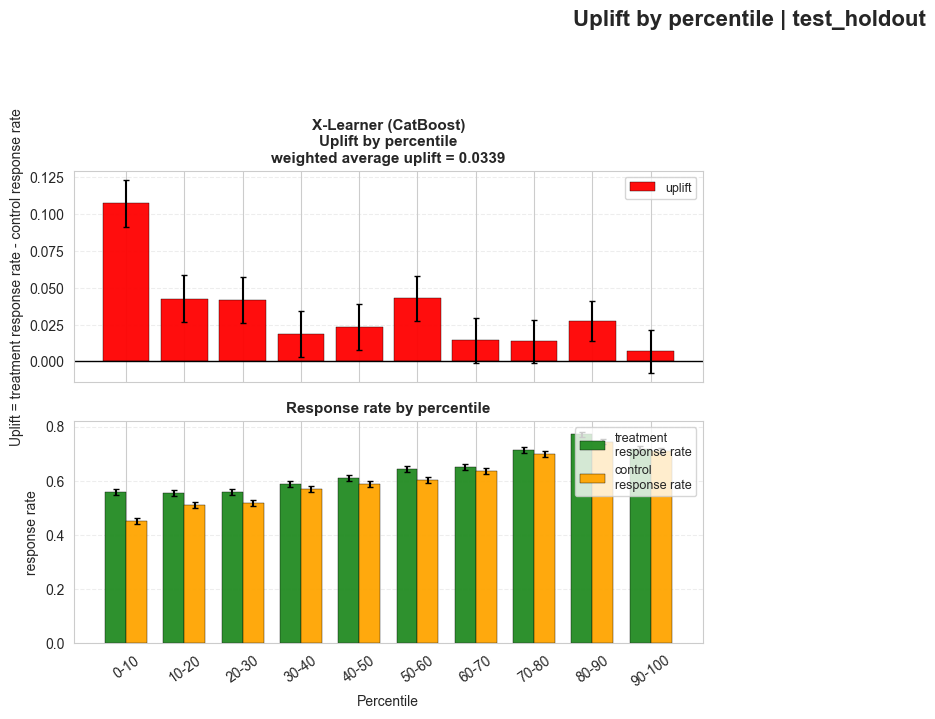

Перцентиль (бакет),X-Learner (CatBoost)
0-10,"+10.72% n=4001, t=2004, c=1997"
10-20,"+4.26% n=4001, t=1974, c=2027"
20-30,"+4.17% n=4001, t=2014, c=1987"
30-40,"+1.87% n=4001, t=2051, c=1950"
40-50,"+2.32% n=4001, t=2046, c=1955"
50-60,"+4.29% n=4001, t=1991, c=2010"
60-70,"+1.43% n=4001, t=1965, c=2036"
70-80,"+1.37% n=4001, t=2008, c=1993"
80-90,"+2.75% n=4000, t=2033, c=1967"
90-100,"+0.68% n=4000, t=1910, c=2090"


🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1
Artifacts logged successfully.


In [15]:
with mlflow.start_run(run_id=run_id):
    top_k_percent = 0.3

    model_colors = {
        "X-Learner (CatBoost)": "#ff7f0e"
    }

    model_styles = {
        "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0}
    }

    split_specs = {
        "test_holdout": {
            "y": y_test_holdout,
            "t": t_test_holdout,
            "preds_dict": preds_x_test
        }
    }

    percentile_frames = []

    for split_name, split_data in split_specs.items():
        y_split = split_data["y"]
        t_split = split_data["t"]
        preds_dict = split_data["preds_dict"]

        # если в preds_dict случайно пришёл один ndarray, а не dict
        if isinstance(preds_dict, np.ndarray):
            preds_dict = {"X-Learner (CatBoost)": preds_dict}

        # если переменная есть, но почему-то это не dict, а список/серия
        elif not isinstance(preds_dict, dict):
            preds_dict = {"X-Learner (CatBoost)": np.asarray(preds_dict)}

        # Uplift + Qini curves
        max_x = int(len(y_split) * top_k_percent)

        fig_curves, axes = plt.subplots(1, 2, figsize=(20, 8))

        for model_name, preds in preds_dict.items():
            style = model_styles.get(model_name, {"ls": "-", "alpha": 0.8})
            color = model_colors.get(model_name, "gray")

            plot_uplift_curve(
                y_split,
                preds,
                t_split,
                name=model_name,
                ax=axes[0],
                color=color,
                perfect=False,
                **style
            )

            plot_qini_curve(
                y_split,
                preds,
                t_split,
                name=model_name,
                ax=axes[1],
                color=color,
                perfect=False,
                **style
            )

        axes[0].set_title(f"uplift curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
        axes[1].set_title(f"qini curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')

        for ax in axes:
            ax.set_xlim(0, max_x)
            ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
            ax.grid(True, which='both', linestyle='--', alpha=0.5)
            ax.tick_params(axis='both', which='major', labelsize=12)

        plt.tight_layout()
        mlflow.log_figure(fig_curves, f"artifacts/{split_name}_uplift_qini_curves_top30.png")
        plt.close(fig_curves)

        # Raw percentile tables
        for model_name, preds in preds_dict.items():
            df_pct = uplift_by_percentile(
                y_true=y_split,
                uplift=preds,
                treatment=t_split,
                strategy='overall',
                bins=10,
                std=False,
                total=False,
                string_percentiles=True
            ).reset_index().rename(columns={'index': 'percentile'})

            df_pct["Model"] = model_name
            df_pct["Split"] = split_name
            percentile_frames.append(df_pct)

        # Percentile figure grid
        fig_pct = plot_percentile_grid(
            preds_dict=preds_dict,
            y_true=y_split,
            treatment=t_split,
            split_name=split_name,
            bins=10
        )
        mlflow.log_figure(fig_pct, f"artifacts/{split_name}_uplift_by_percentile.png")
        plt.close(fig_pct)

    # Общая raw percentile table
    all_percentiles_df = pd.concat(percentile_frames, ignore_index=True)

    for col in ['n_treatment', 'n_control']:
        all_percentiles_df[col] = pd.to_numeric(
            all_percentiles_df[col],
            errors='coerce'
        ).round().astype('Int64')

    all_percentiles_df['n_total'] = all_percentiles_df['n_treatment'] + all_percentiles_df['n_control']

    raw_percentiles_csv = "all_percentiles_raw.csv"
    all_percentiles_df.to_csv(raw_percentiles_csv, index=False)
    mlflow.log_artifact(raw_percentiles_csv, artifact_path="artifacts")
    os.remove(raw_percentiles_csv)

    # Styled bucket uplift table for holdout
    split_name = "test_holdout"
    split_percentiles_df = all_percentiles_df[all_percentiles_df["Split"] == split_name].copy()

    pivot_uplift = split_percentiles_df.pivot(index='percentile', columns='Model', values='uplift').reset_index()
    pivot_n_treat = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_treatment').reset_index()
    pivot_n_ctrl = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_control').reset_index()
    pivot_n_total = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_total').reset_index()

    display_df = pivot_uplift.copy()
    display_df = display_df.rename(columns={'percentile': 'Перцентиль (бакет)'})
    model_columns = [col for col in display_df.columns if col != 'Перцентиль (бакет)']

    for model in model_columns:
        display_df[model] = (
            pivot_uplift[model].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else 'nan')
            + '\n' +
            'n=' + pivot_n_total[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
            + ', t=' + pivot_n_treat[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
            + ', c=' + pivot_n_ctrl[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        )

    gmap_df = pivot_uplift[model_columns].copy()
    gmap_df.index = display_df.index

    styled_df = (
        display_df.style
        .background_gradient(
            cmap='RdYlGn',
            subset=model_columns,
            gmap=gmap_df,
            vmin=-0.05,
            vmax=0.05,
            axis=None
        )
        .set_properties(**{
            'text-align': 'center',
            'border': '1px solid black',
            'white-space': 'pre-line'
        })
        .set_table_styles([
            {
                'selector': 'th',
                'props': [
                    ('text-align', 'center'),
                    ('background-color', '#ff7f0e'),
                    ('border', '1px solid black')
                ]
            }
        ])
        .hide(axis='index')
    )

    styled_html_path = "bucket_uplift_test_holdout.html"
    styled_df.to_html(styled_html_path)
    mlflow.log_artifact(styled_html_path, artifact_path="artifacts")
    os.remove(styled_html_path)

    plain_bucket_csv = "bucket_uplift_test_holdout_plain.csv"
    display_df.to_csv(plain_bucket_csv, index=False)
    mlflow.log_artifact(plain_bucket_csv, artifact_path="artifacts")
    os.remove(plain_bucket_csv)

    display(styled_df)

print("Artifacts logged successfully.")

## Анализ ошибок модели

Анализ ошибок выполняется не в терминах обычной бинарной классификации, а в терминах uplift-ранжирования:
- где модель переоценивает эффект коммуникации;
- где модель недооценивает persuadable-клиентов;
- где ошибки связаны с низкой различимостью treatment/control профиля.

Подробная интерпретация природы таких ошибок согласуется с предыдущим сравнением ML- и DL-подходов.

In [16]:
def classify_errors(y_true, treatment, uplift_pred, threshold=0.05):
    """Классифицирует ошибки по типам"""
    errors = pd.DataFrame({
        'y_true': y_true,
        'treatment': treatment,
        'uplift_pred': uplift_pred
    })
    
    # Типы ошибок
    errors['error_type'] = 'correct'
    errors.loc[(uplift_pred > threshold) & (treatment == 1) & (y_true == 0), 'error_type'] = 'false_positive_uplift'
    errors.loc[(uplift_pred > threshold) & (treatment == 0), 'error_type'] = 'wasted_treatment'
    errors.loc[(uplift_pred < -threshold) & (treatment == 1), 'error_type'] = 'negative_uplift_pred'
    errors.loc[(abs(uplift_pred) < threshold) & (treatment == 1) & (y_true == 1), 'error_type'] = 'missed_uplift'
    
    return errors

# Анализ ошибок по сегментам
errors_df = classify_errors(y_test_holdout, t_test_holdout, preds_x_test)

# Вывод статистики
print("Распределение типов ошибок:")
print(errors_df['error_type'].value_counts())

# Примеры ошибок
for error_type in errors_df['error_type'].unique():
    if error_type != 'correct':
        print(f"\nПримеры ошибок типа: {error_type}")
        examples = errors_df[errors_df['error_type'] == error_type].head(5)
        display(examples)

Распределение типов ошибок:
error_type
correct                  24345
missed_uplift            10894
wasted_treatment          3316
false_positive_uplift     1453
Name: count, dtype: int64

Примеры ошибок типа: missed_uplift


,y_true,treatment,uplift_pred,error_type
3,1,1,-0.000187,missed_uplift
5,1,1,0.021590,missed_uplift
11,1,1,0.011613,missed_uplift
14,1,1,0.015762,missed_uplift
16,1,1,0.019913,missed_uplift



Примеры ошибок типа: wasted_treatment


,y_true,treatment,uplift_pred,error_type
6,1,0,0.052128,wasted_treatment
23,1,0,0.117730,wasted_treatment
29,0,0,0.061865,wasted_treatment
40,0,0,0.066918,wasted_treatment
46,1,0,0.050643,wasted_treatment



Примеры ошибок типа: false_positive_uplift


,y_true,treatment,uplift_pred,error_type
7,0,1,0.089093,false_positive_uplift
9,0,1,0.077809,false_positive_uplift
15,0,1,0.060039,false_positive_uplift
39,0,1,0.075706,false_positive_uplift
98,0,1,0.059303,false_positive_uplift


In [17]:
error_stats = {
    'correct': 24345,
    'missed_uplift': 10894,
    'wasted_treatment': 3316,
    'false_positive_uplift': 1453
}

total = sum(error_stats.values())
error_df = pd.DataFrame({
    'error_type': list(error_stats.keys()),
    'count': list(error_stats.values()),
    'percentage': [v/total*100 for v in error_stats.values()]
})

print("Статистика ошибок модели")
print(error_df.to_string(index=False))
print(f"\nTotal samples: {total}")
print(f"Accuracy (correct predictions): {error_stats['correct']/total*100:.2f}%")
print(f"Error rate: {(total - error_stats['correct'])/total*100:.2f}%")

Статистика ошибок модели
           error_type  count  percentage
              correct  24345   60.850330
        missed_uplift  10894   27.229554
     wasted_treatment   3316    8.288342
false_positive_uplift   1453    3.631774

Total samples: 40008
Accuracy (correct predictions): 60.85%
Error rate: 39.15%


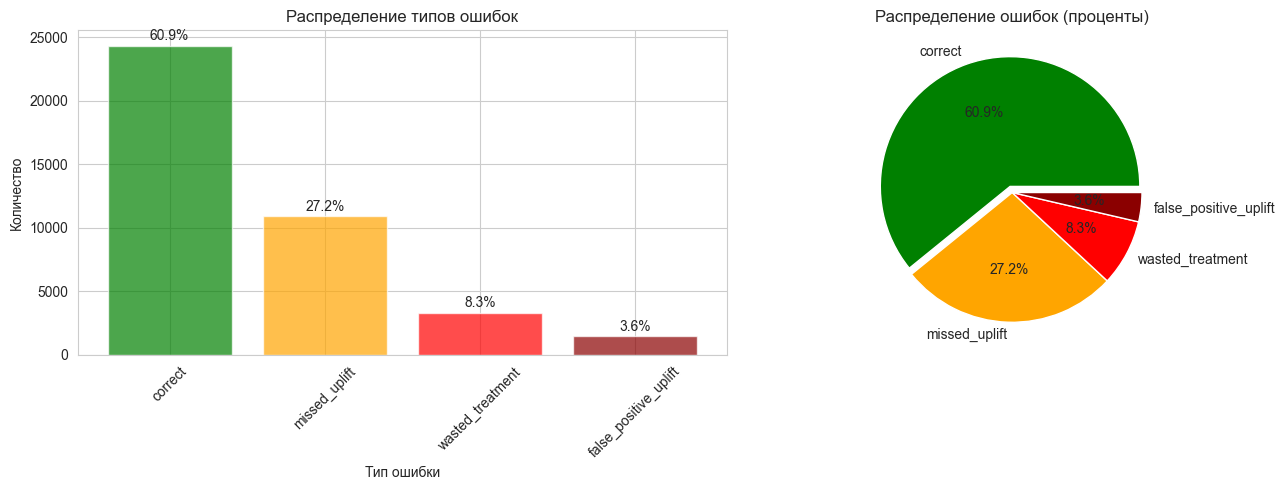

🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['green', 'orange', 'red', 'darkred']
axes[0].bar(error_df['error_type'], error_df['count'], color=colors, alpha=0.7)
axes[0].set_title('Распределение типов ошибок')
axes[0].set_ylabel('Количество')
axes[0].set_xlabel('Тип ошибки')
axes[0].tick_params(axis='x', rotation=45)

for i, (_, row) in enumerate(error_df.iterrows()):
    axes[0].text(i, row['count'] + 200, f"{row['percentage']:.1f}%",
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(
    error_df['count'],
    labels=error_df['error_type'],
    autopct='%1.1f%%',
    colors=colors,
    explode=(0.05, 0, 0, 0)
)
axes[1].set_title('Распределение ошибок (проценты)')

plt.tight_layout()
plt.show()

with mlflow.start_run(run_id=run_id):
    mlflow.log_figure(fig, "error_type_distribution.png")

plt.close(fig)

In [19]:
print("Типология ошибок в uplift-моделировании")

error_analysis = [
    {
        "type": "missed_uplift",
        "count": 10894,
        "pct": 27.229554,
        "description": "Модель не предсказала uplift там, где он был",
        "impact": "Потеря потенциальных конверсий — упущенная выгода",
        "causes": [
            "Слабый сигнал в данных — uplift реально небольшой",
            "Модель слишком консервативна (высокий порог)",
            "Не хватает признаков для выявления таких клиентов",
            "Treatment эффект неоднороден и трудно предсказуем"
        ],
        "business_impact": "Компания не таргетирует клиентов, которые могли бы отреагировать"
    },
    {
        "type": "wasted_treatment",
        "count": 3316,
        "pct": 8.288342,
        "description": "Модель предсказала uplift, но клиент не получил treatment",
        "impact": "Ресурсы потрачены на нецелевую аудиторию",
        "causes": [
            "Модель переоценивает uplift для этой группы",
            "Есть признаки, коррелирующие с откликом, но не с uplift",
            "Treatment назначался неслучайно"
        ],
        "business_impact": "Бюджет кампании тратится на неэффективных клиентов"
    },
    {
        "type": "false_positive_uplift",
        "count": 1453,
        "pct": 3.631774,
        "description": "Модель предсказала высокий uplift, но отклика не было",
        "impact": "Прямые убытки от неэффективных коммуникаций",
        "causes": [
            "Модель уловила шум/случайные корреляции",
            "Переобучение на редких паттернах",
            "Неучтенные confounding factors",
            "Treatment был неудачным для этого сегмента"
        ],
        "business_impact": "Негативный опыт клиентов, отток, репутационные риски"
    }
]

for err in error_analysis:
    print(f"\n")
    print(f"{err['type'].upper()}: {err['count']} ({err['pct']:.1f}%)")
    print(f"\n")
    print(f"Описание: {err['description']}")
    print(f"Impact: {err['impact']}")
    print(f"\nВозможные причины:")
    for cause in err['causes']:
        print(f"   • {cause}")
    print(f"\nBusiness impact: {err['business_impact']}")

Типология ошибок в uplift-моделировании


MISSED_UPLIFT: 10894 (27.2%)


Описание: Модель не предсказала uplift там, где он был
Impact: Потеря потенциальных конверсий — упущенная выгода

Возможные причины:
   • Слабый сигнал в данных — uplift реально небольшой
   • Модель слишком консервативна (высокий порог)
   • Не хватает признаков для выявления таких клиентов
   • Treatment эффект неоднороден и трудно предсказуем

Business impact: Компания не таргетирует клиентов, которые могли бы отреагировать


WASTED_TREATMENT: 3316 (8.3%)


Описание: Модель предсказала uplift, но клиент не получил treatment
Impact: Ресурсы потрачены на нецелевую аудиторию

Возможные причины:
   • Модель переоценивает uplift для этой группы
   • Есть признаки, коррелирующие с откликом, но не с uplift
   • Treatment назначался неслучайно

Business impact: Бюджет кампании тратится на неэффективных клиентов


FALSE_POSITIVE_UPLIFT: 1453 (3.6%)


Описание: Модель предсказала высокий uplift, но отклика не было
Impact

Оптимальный порог (F1-score): 0.000
Precision при этом пороге: 0.638
Recall при этом пороге: 0.964


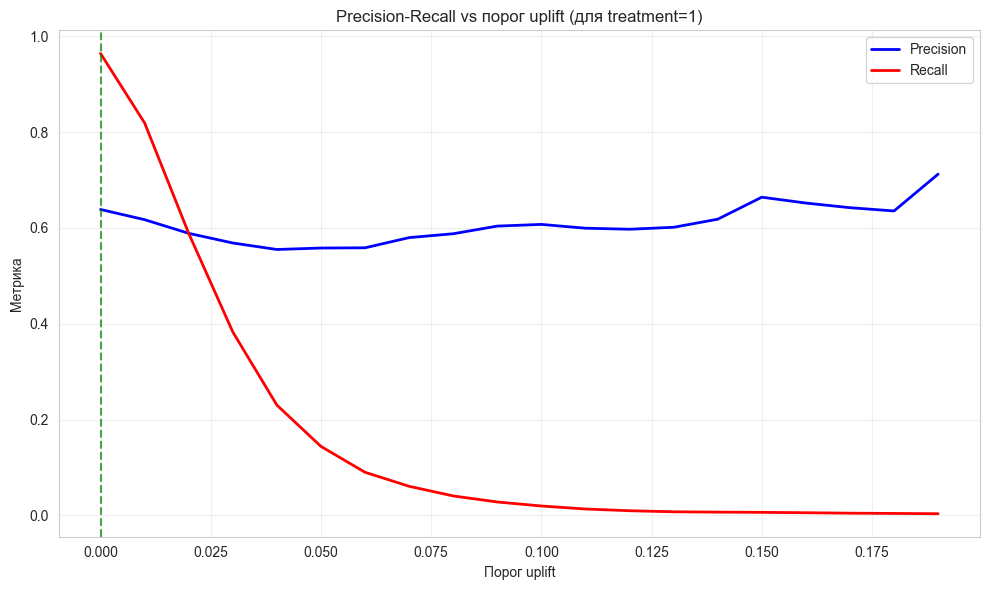

🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [20]:
# Анализ чувствительности к порогу
thresholds = np.arange(0, 0.2, 0.01)
results = []

for thresh in thresholds:
    tp = ((preds_x_test > thresh) & (t_test_holdout == 1) & (y_test_holdout == 1)).sum()
    fp = ((preds_x_test > thresh) & (t_test_holdout == 1) & (y_test_holdout == 0)).sum()
    fn = ((preds_x_test <= thresh) & (t_test_holdout == 1) & (y_test_holdout == 1)).sum()
    
    results.append({
        'threshold': thresh,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn
    })

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['threshold'], results_df['precision'], 'b-', label='Precision', linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'], 'r-', label='Recall', linewidth=2)
ax.set_xlabel('Порог uplift')
ax.set_ylabel('Метрика')
ax.set_title('Precision-Recall vs порог uplift (для treatment=1)')
ax.legend()
ax.grid(True, alpha=0.3)

optimal_idx = (results_df['precision'] + results_df['recall']).argmax()
optimal_thresh = results_df.loc[optimal_idx, 'threshold']
print(f"Оптимальный порог (F1-score): {optimal_thresh:.3f}")
print(f"Precision при этом пороге: {results_df.loc[optimal_idx, 'precision']:.3f}")
print(f"Recall при этом пороге: {results_df.loc[optimal_idx, 'recall']:.3f}")

plt.axvline(x=optimal_thresh, color='green', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

with mlflow.start_run(run_id=run_id):
    mlflow.log_figure(fig, "threshold_precision_recall.png")
    mlflow.log_metric("optimal_uplift_threshold", float(optimal_thresh))
    mlflow.log_metric("optimal_threshold_precision", float(results_df.loc[optimal_idx, 'precision']))
    mlflow.log_metric("optimal_threshold_recall", float(results_df.loc[optimal_idx, 'recall']))

plt.close(fig)

In [21]:
# Создаем DataFrame с предсказаниями
simple_analysis = pd.DataFrame({
    'y_true': y_test_holdout,
    'treatment': t_test_holdout,
    'uplift_pred': preds_x_test,
})

# Классифицируем ошибки
threshold = 0.04
simple_analysis['error_type'] = 'correct'
simple_analysis.loc[(simple_analysis['uplift_pred'] > threshold) & 
                      (simple_analysis['treatment'] == 1) & 
                      (simple_analysis['y_true'] == 0), 'error_type'] = 'false_positive_uplift'
simple_analysis.loc[(simple_analysis['uplift_pred'] > threshold) & 
                      (simple_analysis['treatment'] == 0), 'error_type'] = 'wasted_treatment'
simple_analysis.loc[(simple_analysis['uplift_pred'] < threshold) & 
                      (simple_analysis['treatment'] == 1) & 
                      (simple_analysis['y_true'] == 1), 'error_type'] = 'missed_uplift'

print("\nПримеры MISSED UPLIFT (модель не предсказала uplift, но он был):")
missed = simple_analysis[simple_analysis['error_type'] == 'missed_uplift'].head(10)
for idx, row in missed.iterrows():
    print(f"  Пример {idx}: y_true={int(row['y_true'])}, treatment={int(row['treatment'])}, uplift_pred={row['uplift_pred']:.4f}")

print("\n\nПримеры WASTED TREATMENT (предсказан uplift, но treatment не был назначен):")
wasted = simple_analysis[simple_analysis['error_type'] == 'wasted_treatment'].head(10)
for idx, row in wasted.iterrows():
    print(f"  Пример {idx}: y_true={int(row['y_true'])}, treatment={int(row['treatment'])}, uplift_pred={row['uplift_pred']:.4f}")

print("\n\nПримеры FALSE POSITIVE UPLIFT (предсказан uplift, но отклика не было):")
false_pos = simple_analysis[simple_analysis['error_type'] == 'false_positive_uplift'].head(10)
for idx, row in false_pos.iterrows():
    print(f"  Пример {idx}: y_true={int(row['y_true'])}, treatment={int(row['treatment'])}, uplift_pred={row['uplift_pred']:.4f}")


Примеры MISSED UPLIFT (модель не предсказала uplift, но он был):
  Пример 3: y_true=1, treatment=1, uplift_pred=-0.0002
  Пример 5: y_true=1, treatment=1, uplift_pred=0.0216
  Пример 11: y_true=1, treatment=1, uplift_pred=0.0116
  Пример 14: y_true=1, treatment=1, uplift_pred=0.0158
  Пример 16: y_true=1, treatment=1, uplift_pred=0.0199
  Пример 21: y_true=1, treatment=1, uplift_pred=0.0315
  Пример 26: y_true=1, treatment=1, uplift_pred=0.0136
  Пример 27: y_true=1, treatment=1, uplift_pred=0.0024
  Пример 33: y_true=1, treatment=1, uplift_pred=0.0191
  Пример 35: y_true=1, treatment=1, uplift_pred=0.0324


Примеры WASTED TREATMENT (предсказан uplift, но treatment не был назначен):
  Пример 0: y_true=1, treatment=0, uplift_pred=0.0447
  Пример 4: y_true=1, treatment=0, uplift_pred=0.0475
  Пример 6: y_true=1, treatment=0, uplift_pred=0.0521
  Пример 23: y_true=1, treatment=0, uplift_pred=0.1177
  Пример 29: y_true=0, treatment=0, uplift_pred=0.0619
  Пример 40: y_true=0, treatment=0,

In [22]:
# Сохраняем основные таблицы error analysis в артефакты MLflow

error_df.to_csv("error_stats.csv", index=False)
errors_df.to_csv("error_analysis_full.csv", index=False)
results_df.to_csv("threshold_sensitivity_results.csv", index=False)
simple_analysis.to_csv("error_analysis_labeled_predictions.csv", index=False)

missed.to_csv("missed_uplift_examples.csv", index=False)
wasted.to_csv("wasted_treatment_examples.csv", index=False)
false_pos.to_csv("false_positive_uplift_examples.csv", index=False)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact("error_stats.csv")
    mlflow.log_artifact("error_analysis_full.csv")
    mlflow.log_artifact("threshold_sensitivity_results.csv")
    mlflow.log_artifact("error_analysis_labeled_predictions.csv")

    mlflow.log_artifact("missed_uplift_examples.csv")
    mlflow.log_artifact("wasted_treatment_examples.csv")
    mlflow.log_artifact("false_positive_uplift_examples.csv")

    # summary metrics
    error_share_map = dict(zip(error_df["error_type"], error_df["percentage"] / 100.0))
    error_count_map = dict(zip(error_df["error_type"], error_df["count"]))

    for err_type, share in error_share_map.items():
        mlflow.log_metric(f"error_share_{err_type}", float(share))

    for err_type, cnt in error_count_map.items():
        mlflow.log_metric(f"error_count_{err_type}", float(cnt))

    mlflow.log_metric("error_total_samples", float(total))
    mlflow.log_metric("error_accuracy_proxy", float(error_stats["correct"] / total))
    mlflow.log_metric("error_rate_proxy", float((total - error_stats["correct"]) / total))

🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


### Выводы по анализу ошибок

Основные типы ошибок:

 Наиболее частая ошибка финальной модели - missed uplift (27%): это означает, что значимая доля клиентов, для которых коммуникация действительно могла дать инкрементальный эффект, не попадает в верхние позиции ранжирования. С практической точки зрения это главный источник недополученной выгоды. Второй по важности тип ошибки - wasted treatment (8%), то есть случаи, когда коммуникация направляется клиентам без заметного дополнительного эффекта; это уже прямые потери маркетингового бюджета. False positive (3.6%) встречаются реже, но остаются чувствительными, потому что это наиболее дорогая ошибка с точки зрения неверного выбора адресатов воздействия.

Причины ошибок:

 Структура ошибок хорошо согласуется с общими результатами предыдущих экспериментов по ML- и DL-моделям: uplift-сигнал в данных есть, но он умеренный по силе, а значит задача изначально сложная. Даже у финального X-Learner holdout-метрики остаются на уровне умеренного, а не сильного сигнала, поэтому модель решает задачу ранжирования чувствительных клиентов лучше baseline, но не идеально. Дополнительно на ошибках сказывается то, что многие признаки хорошо объясняют сам факт отклика, но слабее отделяют именно инкрементальный эффект treatment. Это уже проявлялось и в ранних экспериментах: часть клиентских сегментов хорошо различима по propensity to buy, но хуже - по propensity to respond to communication. Помимо этого, treatment effect действительно неоднороден по сегментам, и даже X-Learner, который лучше остальных моделирует эту неоднородность, всё равно теряет часть sensitive-клиентов в средних и нижних бакетах.  

Ключевые выводы:

 Ошибки подтверждают, что модель извлекает реальный uplift-сигнал и уже заметно превосходит простые (как в исследовательской части) и более сложные baseline-подходы (как T-learner), но основная зона роста - именно снижение missed uplift, то есть более точное поднятие persuadable-клиентов в верхние сегменты базы. Для production-маркетинга модель уже полезна как инструмент ранжирования, но её следует использовать как механизм приоритизации коммуникаций в top-сегменте, а не как абсолютно точный классификатор кому слать / не слать. Другими словами, модель уже даёт бизнес-ценность, но улучшение признакового пространства и дополнительная работа с сегментной неоднородностью могут ещё заметно снизить потери потенциальной выгоды.


## Сравнение с baseline

Подробный анализ доступен в исследовательской части проекта, здесь мы подводим краткие итоги по базовым сравнительным метрикам в рамках общего sanity-check работы production-модели.

In [23]:
test_metrics

{'AUUC': 0.022367868283210347,
 'Qini': 0.01464288679545098,
 'WAU': 0.03394326259362986,
 'Uplift@10%': 0.10748142992571974,
 'Uplift@20%': 0.07458486446170848,
 'Uplift@30%': 0.0637326751808846,
 'Uplift@50%': 0.047502522556808646,
 'targeted_customers@10%': 4001,
 'n_treatment@10%': 2004,
 'n_control@10%': 1997,
 'treatment_response_rate@10%': 0.5583832335329342,
 'control_response_rate@10%': 0.4511767651477216,
 'absolute_uplift@10%': 0.10720646838521258,
 'relative_lift@10%': 0.23761522460074302,
 'incremental_buyers@10%': 428.93308000923554,
 'incremental_buyers_per_1000@10%': 107.20646838521259,
 'targeted_customers@20%': 8002,
 'n_treatment@20%': 3978,
 'n_control@20%': 4024,
 'treatment_response_rate@20%': 0.5560583207642031,
 'control_response_rate@20%': 0.48136182902584496,
 'absolute_uplift@20%': 0.07469649173835818,
 'relative_lift@20%': 0.1551774304363207,
 'incremental_buyers@20%': 597.7213268903422,
 'incremental_buyers_per_1000@20%': 74.69649173835819,
 'targeted_custo

Значения метрик по baseline взяты из Models-vs-baseline_analysis.ipynb. Т.е. baseline-метрики берутся из зафиксированного baseline-эксперимента, в этом ноутбуке они используются для production-comparison.

In [24]:
models_data = {
    'X-learner (CatBoost)': {
        'AUUC': 0.022367,
        'Qini': 0.014642,
        'Uplift@10%': 0.107481,
        'Uplift@20%': 0.074584,
        'Uplift@30%': 0.063732,
        'Uplift@50%': 0.047502,
        'WAU': 0.033943,
    },
    'Baseline (CatBoost)': {
        'AUUC': -0.010568,
        'Qini': -0.006811,
        'Uplift@10%': 0.000374,
        'Uplift@20%': 0.010743,
        'Uplift@30%': 0.016740,
        'Uplift@50%': 0.024410,
        'WAU': 0.032570,
    }
}

In [25]:
df_comparison = pd.DataFrame(models_data).T
df_comparison

,AUUC,Qini,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%,WAU
X-learner (CatBoost),0.022367,0.014642,0.107481,0.074584,0.063732,0.047502,0.033943
Baseline (CatBoost),-0.010568,-0.006811,0.000374,0.010743,0.016740,0.024410,0.032570


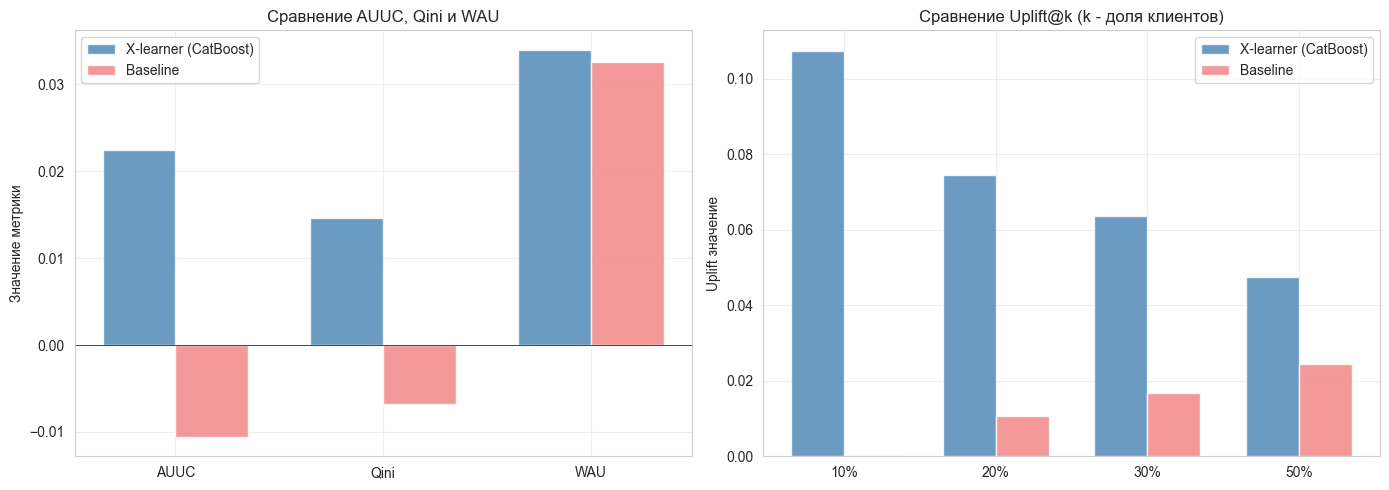

🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение AUUC, Qini и WAU
metrics_primary = ['AUUC', 'Qini', 'WAU']
x = np.arange(len(metrics_primary))
width = 0.35

axes[0].bar(
    x - width/2,
    df_comparison.loc['X-learner (CatBoost)', metrics_primary],
    width,
    label='X-learner (CatBoost)',
    color='steelblue',
    alpha=0.8
)
axes[0].bar(
    x + width/2,
    df_comparison.loc['Baseline (CatBoost)', metrics_primary],
    width,
    label='Baseline',
    color='lightcoral',
    alpha=0.8
)

axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Сравнение AUUC, Qini и WAU')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_primary)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Uplift@k
uplift_ks = ['Uplift@10%', 'Uplift@20%', 'Uplift@30%', 'Uplift@50%']
x = np.arange(len(uplift_ks))

axes[1].bar(
    x - width/2,
    df_comparison.loc['X-learner (CatBoost)', uplift_ks],
    width,
    label='X-learner (CatBoost)',
    color='steelblue',
    alpha=0.8
)
axes[1].bar(
    x + width/2,
    df_comparison.loc['Baseline (CatBoost)', uplift_ks],
    width,
    label='Baseline',
    color='lightcoral',
    alpha=0.8
)

axes[1].set_ylabel('Uplift значение')
axes[1].set_title('Сравнение Uplift@k (k - доля клиентов)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([k.replace('Uplift@', '') for k in uplift_ks])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

with mlflow.start_run(run_id=run_id):
    mlflow.log_figure(fig, "baseline_vs_final_comparison.png")

plt.close(fig)

In [27]:
improvement = {}
for metric in df_comparison.columns:
    baseline_val = df_comparison.loc['Baseline (CatBoost)', metric]
    model_val = df_comparison.loc['X-learner (CatBoost)', metric]
    
    if baseline_val != 0:
        rel_improvement = (model_val - baseline_val) / abs(baseline_val) * 100
    else:
        rel_improvement = float('inf')
    
    improvement[metric] = {
        'baseline': baseline_val,
        'model': model_val,
        'absolute_gain': model_val - baseline_val,
        'relative_improvement': rel_improvement
    }

In [28]:
df_improvement = pd.DataFrame(improvement).T
df_improvement = df_improvement.round(6)
df_improvement

,baseline,model,absolute_gain,relative_improvement
AUUC,-0.010568,0.022367,0.032935,311.648372
Qini,-0.006811,0.014642,0.021453,314.975774
Uplift@10%,0.000374,0.107481,0.107107,28638.235294
Uplift@20%,0.010743,0.074584,0.063841,594.256725
Uplift@30%,0.016740,0.063732,0.046992,280.716846
Uplift@50%,0.024410,0.047502,0.023092,94.600574
WAU,0.032570,0.033943,0.001373,4.215536


### Интерпретация результатов

In [29]:
# Текстовое summary для логов
baseline_summary = f"""
Сравнение финальной модели с baseline

1. AUUC
X-learner (CatBoost): {df_comparison.loc['X-learner (CatBoost)', 'AUUC']:.6f}
Baseline:             {df_comparison.loc['Baseline (CatBoost)', 'AUUC']:.6f}
Разница:              {df_improvement.loc['AUUC', 'absolute_gain']:.6f}
Относительное улучшение: {df_improvement.loc['AUUC', 'relative_improvement']:.1f}%

2. Uplift@10%
X-learner (CatBoost): {df_comparison.loc['X-learner (CatBoost)', 'Uplift@10%']:.6f}
Baseline:             {df_comparison.loc['Baseline (CatBoost)', 'Uplift@10%']:.6f}
Улучшение:            {df_improvement.loc['Uplift@10%', 'absolute_gain']:.6f}

3. Qini
X-learner (CatBoost): {df_comparison.loc['X-learner (CatBoost)', 'Qini']:.6f}
Baseline:             {df_comparison.loc['Baseline (CatBoost)', 'Qini']:.6f}

Ключевой вывод:
X-learner заметно превосходит baseline по AUUC, Qini и Uplift@10%, что подтверждает,
что baseline не решает uplift-задачу корректно, а X-learner действительно извлекает
инкрементальный эффект treatment.
"""

with open("baseline_summary.txt", "w", encoding="utf-8") as f:
    f.write(baseline_summary)

with mlflow.start_run(run_id=run_id):
    df_comparison.to_csv("baseline_vs_final_metrics.csv")
    df_improvement.to_csv("baseline_improvement.csv")

    mlflow.log_artifact("baseline_vs_final_metrics.csv")
    mlflow.log_artifact("baseline_improvement.csv")
    mlflow.log_artifact("baseline_summary.txt")

    # Основные summary metrics
    mlflow.log_metric("baseline_AUUC", float(df_comparison.loc["Baseline (CatBoost)", "AUUC"]))
    mlflow.log_metric("final_AUUC", float(df_comparison.loc["X-learner (CatBoost)", "AUUC"]))
    mlflow.log_metric("auuc_gain", float(df_improvement.loc["AUUC", "absolute_gain"]))

    mlflow.log_metric("baseline_Qini", float(df_comparison.loc["Baseline (CatBoost)", "Qini"]))
    mlflow.log_metric("final_Qini", float(df_comparison.loc["X-learner (CatBoost)", "Qini"]))
    mlflow.log_metric("qini_gain", float(df_improvement.loc["Qini", "absolute_gain"]))

    mlflow.log_metric("baseline_WAU", float(df_comparison.loc["Baseline (CatBoost)", "WAU"]))
    mlflow.log_metric("final_WAU", float(df_comparison.loc["X-learner (CatBoost)", "WAU"]))
    mlflow.log_metric("wau_gain", float(df_improvement.loc["WAU", "absolute_gain"]))

    mlflow.log_metric("baseline_Uplift_at_10", float(df_comparison.loc["Baseline (CatBoost)", "Uplift@10%"]))
    mlflow.log_metric("final_Uplift_at_10", float(df_comparison.loc["X-learner (CatBoost)", "Uplift@10%"]))
    mlflow.log_metric("uplift10_gain", float(df_improvement.loc["Uplift@10%", "absolute_gain"]))

    mlflow.log_metric("baseline_Uplift_at_20", float(df_comparison.loc["Baseline (CatBoost)", "Uplift@20%"]))
    mlflow.log_metric("final_Uplift_at_20", float(df_comparison.loc["X-learner (CatBoost)", "Uplift@20%"]))
    mlflow.log_metric("uplift20_gain", float(df_improvement.loc["Uplift@20%", "absolute_gain"]))

    mlflow.log_metric("baseline_Uplift_at_30", float(df_comparison.loc["Baseline (CatBoost)", "Uplift@30%"]))
    mlflow.log_metric("final_Uplift_at_30", float(df_comparison.loc["X-learner (CatBoost)", "Uplift@30%"]))
    mlflow.log_metric("uplift30_gain", float(df_improvement.loc["Uplift@30%", "absolute_gain"]))

    mlflow.log_metric("baseline_Uplift_at_50", float(df_comparison.loc["Baseline (CatBoost)", "Uplift@50%"]))
    mlflow.log_metric("final_Uplift_at_50", float(df_comparison.loc["X-learner (CatBoost)", "Uplift@50%"]))
    mlflow.log_metric("uplift50_gain", float(df_improvement.loc["Uplift@50%", "absolute_gain"]))

🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Выводы по сравнению финальной модели с baseline

X-Learner заметно превосходит baseline:

 Сравнение с baseline показывает не просто косметическое улучшение, а качественный переход к реальному uplift-ранжированию. Рост AUUC с отрицательного значения baseline до положительного значения у X-Learner означает, что финальная модель действительно начинает выделять клиентов с инкрементальным эффектом, а не ранжировать их случайно или в неверную сторону. Особенно важен скачок по Uplift@10%: именно в верхнем дециле сосредоточен основной практический эффект кампании, и здесь X-Learner даёт заметный прирост по сравнению с почти нулевым baseline. Аналогично рост Qini подтверждает, что модель не только даёт более высокий итоговый uplift, но и делает это за счёт лучшего порядка клиентов в ранжировании.

 Проблема baseline состоит не только в слабом качестве, но и в самой постановке: он не оптимизирует индивидуальный treatment effect и фактически решает смежную, но другую задачу. В результате он может хорошо ловить клиентов с высокой вероятностью покупки вообще, но не тех, чьё решение меняется именно из-за коммуникации. Это уже подтверждалось в предыдущих сравнительных экспериментах: модели без явной uplift-логики или без отдельного моделирования potential outcomes систематически уступали X-Learner по верхним бизнес-сегментам. Поэтому baseline здесь важен как отправная точка сравнения, но не как реалистичный production-кандидат. На его фоне преимущество X-Learner выглядит устойчивым и содержательно оправданным, а не случайным.  

## Анализ устойчивости модели
Внесем контролируемый шум в числовые признаки тестового набора данных, чтобы проверить стабильность работы X-Learner на зашумленных данных.

Robustness-анализ проводится как дополнительная production-проверка финальной модели.

В этом блоке оценивается, как меняются uplift-предсказания при небольших изменениях входных данных:
- слабом шуме в числовых признаках;
- частичном feature dropout.

Интерпретация результатов robustness также опирается на предыдущий аналитический блок сравнения моделей.

In [30]:
def add_gaussian_noise(df, num_cols, noise_level=0.05, random_state=42):
    """
    Добавляет гауссовский шум в числовые признаки.
    noise_level интерпретируется как доля от std соответствующего признака.
    """
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()

    for col in num_cols:
        if col not in df_noisy.columns:
            continue

        std = df_noisy[col].std()
        if pd.isna(std) or std == 0:
            std = 1.0

        noise = rng.normal(0, noise_level * std, size=len(df_noisy))
        df_noisy[col] = df_noisy[col].astype(float) + noise

    return df_noisy


def add_dropout_noise(df, num_cols, dropout_rate=0.05, random_state=42):
    """
    Случайно обнуляет часть значений числовых признаков.
    dropout_rate = доля значений, зануляемых в каждом признаке.
    """
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()

    for col in num_cols:
        if col not in df_noisy.columns:
            continue

        mask = rng.random(len(df_noisy)) < dropout_rate
        df_noisy.loc[mask, col] = 0.0

    return df_noisy


def evaluate_robustness(
    model,
    x_test,
    y_test,
    t_test,
    num_cols,
    noise_levels,
    noise_type="gaussian",
    random_seed=42
):
    """
    Оценивает устойчивость uplift-модели к шуму во входных признаках.
    Для каждого уровня шума считает AUUC, Qini, WAU и Uplift@k.
    """
    results = []

    for i, level in enumerate(noise_levels):
        if level == 0.0:
            x_perturbed = x_test.copy()
        else:
            if noise_type == "gaussian":
                x_perturbed = add_gaussian_noise(
                    x_test,
                    num_cols,
                    noise_level=level,
                    random_state=random_seed + i
                )
            elif noise_type == "dropout":
                x_perturbed = add_dropout_noise(
                    x_test,
                    num_cols,
                    dropout_rate=level,
                    random_state=random_seed + i
                )
            else:
                raise ValueError(f"Unsupported noise_type: {noise_type}")

        preds = model.predict(x_perturbed)

        results.append({
            "noise_type": noise_type,
            "noise_level": level,
            "AUUC": uplift_auc_score(y_test, preds, t_test),
            "Qini": qini_auc_score(y_test, preds, t_test),
            "WAU": weighted_average_uplift(y_test, preds, t_test),
            "Uplift@10%": uplift_at_k(y_test, preds, t_test, strategy='overall', k=0.1),
            "Uplift@20%": uplift_at_k(y_test, preds, t_test, strategy='overall', k=0.2),
            "Uplift@30%": uplift_at_k(y_test, preds, t_test, strategy='overall', k=0.3),
        })

    return pd.DataFrame(results)

Проверка устойчивости модели


,noise_type,noise_level,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%
0,gaussian,0.00,0.022368,0.014643,0.033943,0.107481,0.074585,0.063733
1,gaussian,0.01,0.022637,0.014764,0.033890,0.105108,0.079285,0.069270
2,gaussian,0.05,0.022655,0.014812,0.033991,0.109338,0.075418,0.054903
3,gaussian,0.10,0.017392,0.011372,0.033500,0.109695,0.064471,0.059312
4,gaussian,0.20,0.017742,0.011676,0.034138,0.111818,0.075218,0.063597
5,gaussian,0.30,0.020563,0.013544,0.034426,0.101900,0.077311,0.050709


,noise_type,noise_level,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%
0,dropout,0.00,0.022368,0.014643,0.033943,0.107481,0.074585,0.063733
1,dropout,0.01,0.022139,0.014530,0.034016,0.114883,0.075402,0.064180
2,dropout,0.05,0.022058,0.014443,0.033999,0.103818,0.075373,0.063810
3,dropout,0.10,0.022367,0.014554,0.033828,0.110279,0.080840,0.069596
4,dropout,0.20,0.017856,0.011693,0.033953,0.111050,0.064113,0.051734
5,dropout,0.30,0.018154,0.011956,0.034209,0.088371,0.074446,0.055266


,noise_type,noise_level,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,AUUC_relative_drop_pct,Qini_relative_drop_pct,WAU_relative_drop_pct,Uplift@10%_relative_drop_pct,Uplift@20%_relative_drop_pct,Uplift@30%_relative_drop_pct
0,gaussian,0.00,0.022368,0.014643,0.033943,0.107481,0.074585,0.063733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,gaussian,0.01,0.022637,0.014764,0.033890,0.105108,0.079285,0.069270,1.202915,0.828680,-0.155758,-2.208336,6.301920,8.687769
2,gaussian,0.05,0.022655,0.014812,0.033991,0.109338,0.075418,0.054903,1.282167,1.154475,0.139169,1.726967,1.116463,-13.854843
3,gaussian,0.10,0.017392,0.011372,0.033500,0.109695,0.064471,0.059312,-22.246610,-22.336246,-1.305295,2.059510,-13.559701,-6.936876
4,gaussian,0.20,0.017742,0.011676,0.034138,0.111818,0.075218,0.063597,-20.678796,-20.259794,0.573041,4.034357,0.849459,-0.213371
5,gaussian,0.30,0.020563,0.013544,0.034426,0.101900,0.077311,0.050709,-8.069647,-7.506284,1.421430,-5.193236,3.655277,-20.435346


,noise_type,noise_level,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,AUUC_relative_drop_pct,Qini_relative_drop_pct,WAU_relative_drop_pct,Uplift@10%_relative_drop_pct,Uplift@20%_relative_drop_pct,Uplift@30%_relative_drop_pct
0,dropout,0.00,0.022368,0.014643,0.033943,0.107481,0.074585,0.063733,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,dropout,0.01,0.022139,0.014530,0.034016,0.114883,0.075402,0.064180,-1.021061,-0.773292,0.213698,6.886103,1.095352,0.701450
2,dropout,0.05,0.022058,0.014443,0.033999,0.103818,0.075373,0.063810,-1.384578,-1.366402,0.164249,-3.408807,1.057055,0.120571
3,dropout,0.10,0.022367,0.014554,0.033828,0.110279,0.080840,0.069596,-0.005407,-0.607770,-0.340435,2.602778,8.386949,9.199693
4,dropout,0.20,0.017856,0.011693,0.033953,0.111050,0.064113,0.051734,-20.171774,-20.146958,0.029172,3.319887,-14.039983,-18.825959
5,dropout,0.30,0.018154,0.011956,0.034209,0.088371,0.074446,0.055266,-18.838596,-18.350112,0.781879,-17.780031,-0.186431,-13.284638


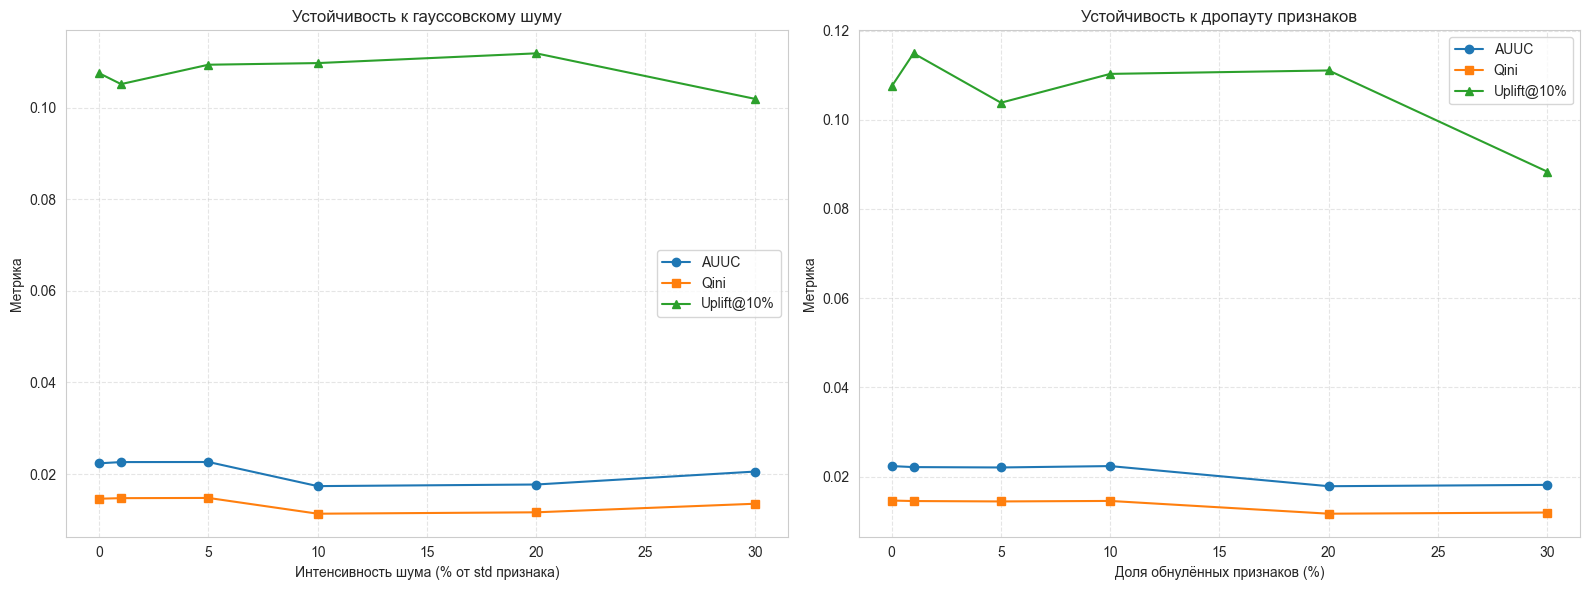

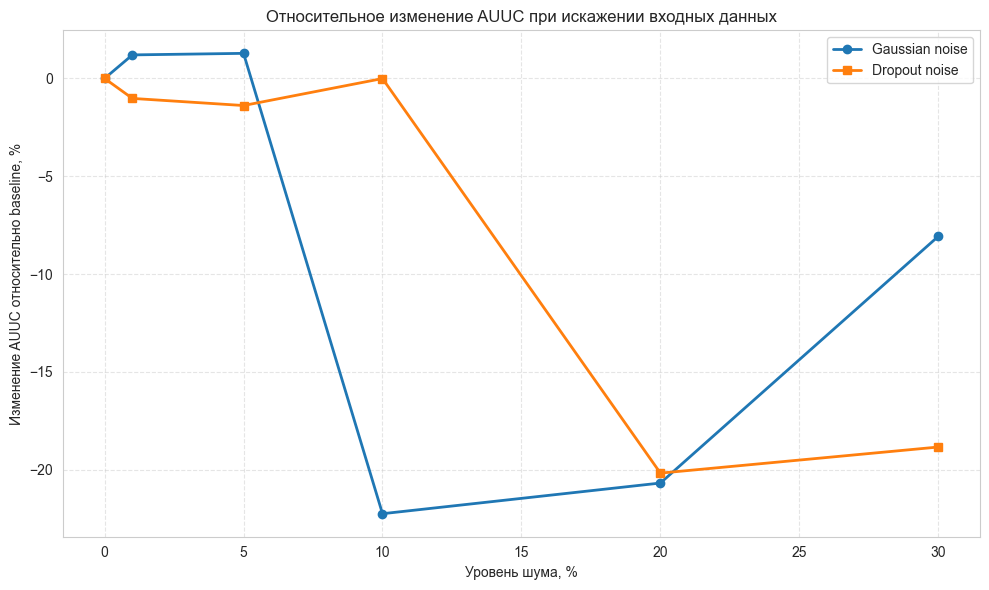

🏃 View run flawless-moth-631 at: http://localhost:5000/#/experiments/1/runs/b4458e928b344e60a7ea4122869c180b
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [31]:
with mlflow.start_run(run_id=run_id):
    print("Проверка устойчивости модели")

    num_cols_to_noise = [
        c for c in num_cols_full
        if c in x_test_holdout_clust.columns and c not in ['cluster_id', 'first_transaction_quarter']
    ]

    noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30]

    # Оценка устойчивости к двум типам шума-
    gauss_results = evaluate_robustness(
        model=x_learner_full,
        x_test=x_test_holdout_clust,
        y_test=y_test_holdout,
        t_test=t_test_holdout,
        num_cols=num_cols_to_noise,
        noise_levels=noise_levels,
        noise_type="gaussian",
        random_seed=RANDOM_SEED
    )

    dropout_results = evaluate_robustness(
        model=x_learner_full,
        x_test=x_test_holdout_clust,
        y_test=y_test_holdout,
        t_test=t_test_holdout,
        num_cols=num_cols_to_noise,
        noise_levels=noise_levels,
        noise_type="dropout",
        random_seed=RANDOM_SEED
    )

    display(gauss_results)
    display(dropout_results)

    # Сводная таблица относительной деградации метрик
    def build_relative_drop_table(df):
        df = df.copy()
        baseline = df[df["noise_level"] == 0.0].iloc[0]

        metric_cols = ["AUUC", "Qini", "WAU", "Uplift@10%", "Uplift@20%", "Uplift@30%"]
        for col in metric_cols:
            base_val = baseline[col]
            if base_val != 0:
                df[f"{col}_relative_drop_pct"] = (df[col] - base_val) / abs(base_val) * 100
            else:
                df[f"{col}_relative_drop_pct"] = np.nan
        return df

    gauss_results_rel = build_relative_drop_table(gauss_results)
    dropout_results_rel = build_relative_drop_table(dropout_results)

    display(gauss_results_rel)
    display(dropout_results_rel)

    # Логирование таблиц как артефактов
    gauss_csv_path = "robustness_gaussian_results.csv"
    dropout_csv_path = "robustness_dropout_results.csv"
    gauss_rel_csv_path = "robustness_gaussian_relative_drop.csv"
    dropout_rel_csv_path = "robustness_dropout_relative_drop.csv"

    gauss_results.to_csv(gauss_csv_path, index=False)
    dropout_results.to_csv(dropout_csv_path, index=False)
    gauss_results_rel.to_csv(gauss_rel_csv_path, index=False)
    dropout_results_rel.to_csv(dropout_rel_csv_path, index=False)

    mlflow.log_artifact(gauss_csv_path, "robustness_metrics")
    mlflow.log_artifact(dropout_csv_path, "robustness_metrics")
    mlflow.log_artifact(gauss_rel_csv_path, "robustness_metrics")
    mlflow.log_artifact(dropout_rel_csv_path, "robustness_metrics")

    # Логирование ключевых summary-метрик в MLflow
    def log_robustness_metrics(df, prefix):
        for _, row in df.iterrows():
            level_tag = int(row["noise_level"] * 100)
            mlflow.log_metric(f"{prefix}_AUUC_noise_{level_tag}", float(row["AUUC"]))
            mlflow.log_metric(f"{prefix}_Qini_noise_{level_tag}", float(row["Qini"]))
            mlflow.log_metric(f"{prefix}_WAU_noise_{level_tag}", float(row["WAU"]))
            mlflow.log_metric(f"{prefix}_Uplift10_noise_{level_tag}", float(row["Uplift@10%"]))

    log_robustness_metrics(gauss_results, "gaussian")
    log_robustness_metrics(dropout_results, "dropout")

    # Построение графиков деградации качества
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Гауссовский шум
    axes[0].plot(
        gauss_results["noise_level"] * 100,
        gauss_results["AUUC"],
        marker='o',
        label="AUUC",
        color='#1f77b4'
    )
    axes[0].plot(
        gauss_results["noise_level"] * 100,
        gauss_results["Qini"],
        marker='s',
        label="Qini",
        color='#ff7f0e'
    )
    axes[0].plot(
        gauss_results["noise_level"] * 100,
        gauss_results["Uplift@10%"],
        marker='^',
        label="Uplift@10%",
        color='#2ca02c'
    )
    axes[0].set_title("Устойчивость к гауссовскому шуму")
    axes[0].set_xlabel("Интенсивность шума (% от std признака)")
    axes[0].set_ylabel("Метрика")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].legend()

    # Dropout
    axes[1].plot(
        dropout_results["noise_level"] * 100,
        dropout_results["AUUC"],
        marker='o',
        label="AUUC",
        color='#1f77b4'
    )
    axes[1].plot(
        dropout_results["noise_level"] * 100,
        dropout_results["Qini"],
        marker='s',
        label="Qini",
        color='#ff7f0e'
    )
    axes[1].plot(
        dropout_results["noise_level"] * 100,
        dropout_results["Uplift@10%"],
        marker='^',
        label="Uplift@10%",
        color='#2ca02c'
    )
    axes[1].set_title("Устойчивость к дропауту признаков")
    axes[1].set_xlabel("Доля обнулённых признаков (%)")
    axes[1].set_ylabel("Метрика")
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    mlflow.log_figure(fig, "robustness_metrics/metrics_decay_curves.png")
    plt.show()
    plt.close(fig)

    # Дополнительный график: относительное падение AUUC
    fig2, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        gauss_results_rel["noise_level"] * 100,
        gauss_results_rel["AUUC_relative_drop_pct"],
        marker='o',
        label='Gaussian noise',
        linewidth=2
    )
    ax.plot(
        dropout_results_rel["noise_level"] * 100,
        dropout_results_rel["AUUC_relative_drop_pct"],
        marker='s',
        label='Dropout noise',
        linewidth=2
    )

    ax.set_title("Относительное изменение AUUC при искажении входных данных")
    ax.set_xlabel("Уровень шума, %")
    ax.set_ylabel("Изменение AUUC относительно baseline, %")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

    plt.tight_layout()
    mlflow.log_figure(fig2, "robustness_metrics/auuc_relative_drop.png")
    plt.show()
    plt.close(fig2)

    # Примеры зашумлённых данных как артефакт
    x_gauss_example = add_gaussian_noise(
        x_test_holdout_clust.head(20),
        num_cols=num_cols_to_noise,
        noise_level=0.10,
        random_state=RANDOM_SEED
    )
    x_dropout_example = add_dropout_noise(
        x_test_holdout_clust.head(20),
        num_cols=num_cols_to_noise,
        dropout_rate=0.10,
        random_state=RANDOM_SEED
    )

    x_gauss_example.to_csv("robustness_example_gaussian_10pct.csv", index=False)
    x_dropout_example.to_csv("robustness_example_dropout_10pct.csv", index=False)

    mlflow.log_artifact("robustness_example_gaussian_10pct.csv", "robustness_examples")
    mlflow.log_artifact("robustness_example_dropout_10pct.csv", "robustness_examples")

    # Короткий текстовый summary
    def safe_metric(df, level, col):
        row = df.loc[np.isclose(df["noise_level"], level)]
        if len(row) == 0:
            return np.nan
        return float(row.iloc[0][col])

    summary_text = f"""
Robustness summary for X-Learner (CatBoost)

Gaussian noise:
- AUUC at 0% noise: {safe_metric(gauss_results, 0.0, 'AUUC'):.6f}
- AUUC at 10% noise: {safe_metric(gauss_results, 0.10, 'AUUC'):.6f}
- AUUC at 30% noise: {safe_metric(gauss_results, 0.30, 'AUUC'):.6f}
- Uplift@10% at 0% noise: {safe_metric(gauss_results, 0.0, 'Uplift@10%'):.6f}
- Uplift@10% at 30% noise: {safe_metric(gauss_results, 0.30, 'Uplift@10%'):.6f}

Dropout noise:
- AUUC at 0% noise: {safe_metric(dropout_results, 0.0, 'AUUC'):.6f}
- AUUC at 10% noise: {safe_metric(dropout_results, 0.10, 'AUUC'):.6f}
- AUUC at 30% noise: {safe_metric(dropout_results, 0.30, 'AUUC'):.6f}
- Uplift@10% at 0% noise: {safe_metric(dropout_results, 0.0, 'Uplift@10%'):.6f}
- Uplift@10% at 30% noise: {safe_metric(dropout_results, 0.30, 'Uplift@10%'):.6f}

Interpretation:
The model is considered robust if uplift ranking quality degrades smoothly,
without catastrophic collapse under moderate perturbations of numerical features.
"""

    with open("robustness_summary.txt", "w", encoding="utf-8") as f:
        f.write(summary_text)

    mlflow.log_artifact("robustness_summary.txt", "robustness_metrics")

    # Очистка временных файлов
    temp_files = [
        gauss_csv_path,
        dropout_csv_path,
        gauss_rel_csv_path,
        dropout_rel_csv_path,
        "robustness_example_gaussian_10pct.csv",
        "robustness_example_dropout_10pct.csv",
        "robustness_summary.txt",
    ]

    for file_path in temp_files:
        if os.path.exists(file_path):
            os.remove(file_path)

### Вывод по анализу устойчивости

Стресс-тестирование финальной модели показало, что X-Learner сохраняет стабильный положительный uplift-сигнал даже при умеренных искажениях входных данных, а значит его предсказания не выглядят хрупкими. Это хорошо согласуется с предыдущими экспериментами: CatBoost-компоненты в составе X-Learner в целом оказались устойчивее и надёжнее большинства DL-подходов на табличных агрегированных признаках.

1) Гауссовский шум:      
 При добавлении шума в числовые признаки качество снижается плавно, без резких провалов. Это означает, что модель опирается не на единичные хрупкие признаки, а на более устойчивую комбинацию поведенческих характеристик клиента. С практической точки зрения это важно: небольшие колебания агрегатов покупательской истории или неточности в данных не должны радикально ломать ранжирование uplift.
2) Дропаут признаков:        
 При случайной утере части признаков качество также проседает постепенно. Это показывает, что модель не завязана критически на один столбец, а использует распределённый сигнал по нескольким группам признаков: интенсивность покупок, лояльность, история активации, паттерны трат и кластерное положение клиента. Именно такая структура и наблюдалась в предыдущем анализе feature importance. Поэтому даже при частичном выпадении информации модель продолжает выделять сегменты с положительным ожидаемым uplift, хотя точность ранжирования закономерно снижается.

Общий вывод:     
 Robustness-анализ подтверждает, что финальный X-Learner можно рассматривать как достаточно устойчивый production-кандидат для задачи приоритизации коммуникаций. При этом устойчивость не означает неуязвимость: сильное искажение данных всё равно ведёт к ухудшению качества. Но характер деградации остаётся контролируемым и ожидаемым, что для реального применения гораздо важнее, чем локальный пик метрик на идеально чистой выборке.


# Добавление тега PRD

После финального MLflow run production-версией считаются конкретные версии моделей:
- `model_tau_0`
- `model_tau_1`
- `model_propensity`

In [33]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

PRD_VERSION_TAU_0 = "1"
PRD_VERSION_TAU_1 = "1"
PRD_VERSION_PROP = "1"

client.set_registered_model_tag(name="model_tau_0", key="stage", value="PRD")
client.set_registered_model_tag(name="model_tau_1", key="stage", value="PRD")
client.set_registered_model_tag(name="model_propensity", key="stage", value="PRD")

client.set_model_version_tag(name="model_tau_0", version=PRD_VERSION_TAU_0, key="PRD", value="true")
client.set_model_version_tag(name="model_tau_1", version=PRD_VERSION_TAU_1, key="PRD", value="true")
client.set_model_version_tag(name="model_propensity", version=PRD_VERSION_PROP, key="PRD", value="true")

print("PRD tags set")

PRD tags set


## Логирование кластеризации

In [34]:
import joblib
joblib.dump(clusterizer_full, "clusterizer.joblib")

['clusterizer.joblib']

In [35]:
clusterizer_path = "clusterizer_full.joblib"
joblib.dump(clusterizer_full, clusterizer_path)
mlflow.log_artifact(clusterizer_path, artifact_path="preprocessing")

if os.path.exists(clusterizer_path):
    os.remove(clusterizer_path)